# `Genesis` demo — mobile dual-arm FR3 

This notebook shows how to use the reusable `RobotScene` class from
`scripts/scene_robot_tables.py`:

1. **Start** the simulation environment
2. **Drive the base** around the scene (forward / strafe / rotate)
3. **Control individual joints** (arms + grippers)
4. **Use IK** to move the left / right arm end-effectors

## 1. Start the simulation

Toggle **`HEADLESS`** below:
* `HEADLESS = True` — no viewer window; you only see the inline frames (`show()`) and the
  final mp4. This is the right choice for a remote/browser kernel with no display.
* `HEADLESS = False` — opens the native Genesis viewer window (a separate desktop window;
  it does **not** appear inside the browser). Requires a display (`DISPLAY` set). The inline
  `show()` frames and the mp4 still work in addition to the window.

In [1]:
import os, sys
import numpy as np
import cv2
import ipywidgets as widgets
from IPython.display import display
from sidecar import Sidecar

# Make the script importable from this notebook.
sys.path.insert(0, os.path.abspath("../scripts"))

from scene_robot_tables import RobotScene

# Toggle this: True = no viewer window (offscreen only),
#              False = also open the native Genesis viewer (needs a display).
HEADLESS = True

sim = RobotScene(headless=HEADLESS, save_video=True)

sim.start_recording()   # begin accumulating frames for the final mp4

[I 06/04/26 09:43:11.516 32698] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[backend] using: cuda
[Genesis] [09:43:13] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [09:43:13] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [09:43:13] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [09:43:13] [INFO] Running on [NVIDIA GeForce RTX 2070] with backend gs.cuda. Device memory: 7.60 GB.
[Genesis] [09:43:13] [INFO] 🚀 Genesis initialized. 🔖 version: 1.0.0, 🎨 theme: light, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO


[Genesis] [09:43:24] [WARNING] Link 'imagetostl_mesh_0_009' has dubious mass 138.425 compared to the estimate from geometry 0.091 given material density 600.
[Genesis] [09:43:24] [WARNING] Link 'imagetostl_mesh_0_011' has dubious mass 15.822 compared to the estimate from geometry 0.017 given material density 600.
[Genesis] [09:43:24] [WARNING] Ignoring inertia matrix of link 'argo_drive_front_link' because center of mass is not specified.
[Genesis] [09:43:24] [WARNING] Ignoring inertia matrix of link 'argo_drive_rear_link' because center of mass is not specified.
[Genesis] [09:43:26] [WARNING] Neutral robot position (qpos0) exceeds joint limits.
[Genesis] [09:43:38] [WARNING] Filtered out geometry pairs causing self-collision for the neutral configuration (qpos0): (94, 105), (94, 106), (94, 109), (94, 110), (96, 106), (98, 110), (117, 121), (117, 122), (117, 129), (118, 123), (118, 124), (118, 137), (128, 132), (136, 140). Consider tuning Morph option 'decompose_robot_error_threshold' 

In [2]:
import matplotlib.pyplot as plt

def show(img, title=None):
    """Render one frame from the offscreen camera and display it inline."""
    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 2. Drive the base

`sim.set_base_velocity(vx, vy, wz, steps)` sets a body-frame velocity and advances the simulation:
* `vx` — forward (+) / back (−), m/s
* `vy` — strafe left (+) / right (−), m/s
* `wz` — rotate in place, left (+) / right (−), rad/s

The dual-steer wheels and a heading-hold controller are handled internally.

start base pose: [-0.   4.5 -0. ]


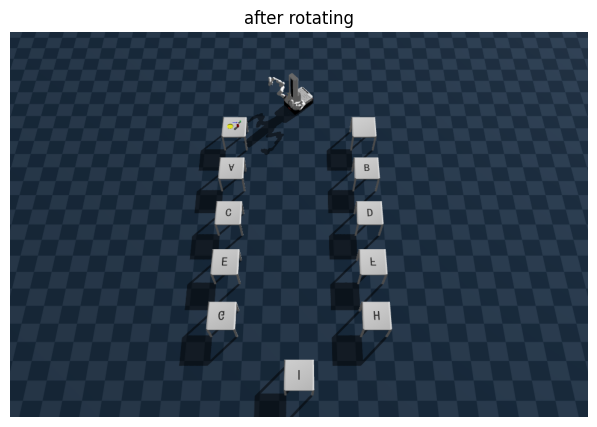

In [ ]:
print("start base pose:", np.round(sim.get_base_pose()[0], 3))

sim.set_base_velocity(0.0, 0.0, -1.2)   # rotate in place (left)
sim.step(500)
# show(sim.render_head(), "after rotating")
show(sim.render(), "after rotating")


sim.set_base_velocity(0.5, 0.0, 0.0)    # forward
sim.step(500)
show(sim.render(), "after driving forward")


sim.set_base_velocity(0.0, 0.5, 0.0)    # strafe left
sim.step(500)
show(sim.render(), "after strafing left")

sim.stop_base()
pos, yaw = sim.get_base_pose()
print("end base pose:", np.round(pos, 3), "yaw(deg):", round(np.degrees(yaw), 1))

## 3. Control individual joints

Each arm has 7 joints and a 2-finger gripper. Set position targets directly:
* `sim.set_arm(side, q)` — 7 joint angles (rad) for `side` in `'left'` / `'right'`
* `sim.set_gripper(side, opening)` — finger opening in meters (`0.0` closed .. `0.04` open)

Targets are held every simulation step; pass `step=True, steps=N` to advance immediately.

left arm q (rad): [-0.   -1.5   0.   -2.2   0.    1.5   0.79]


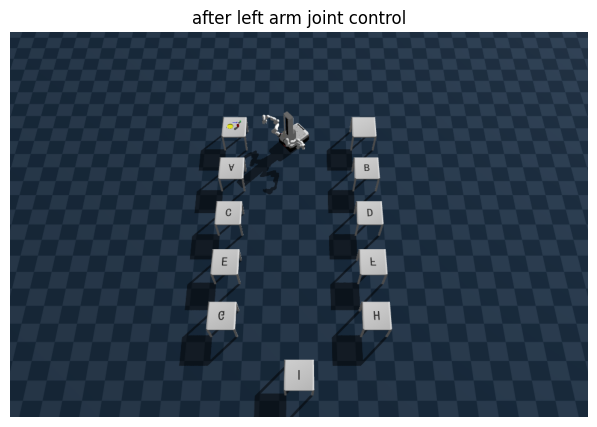

In [ ]:
# Read the current left-arm joint angles, then bend joint 4 (elbow) and joint 6 (wrist).
q_left = sim.get_arm("left").copy()
print("left arm q (rad):", np.round(q_left, 2))

q_left[3] += 0.6    # joint4
q_left[5] -= 0.5    # joint6
sim.set_arm("left", q_left)
sim.step(120)

show(sim.render(), "after left arm joint control")

# Close then open the left gripper.
sim.set_gripper("left", 0.0)     # close
sim.step(200)
sim.set_gripper("left", 0.04)    # open again
sim.step(200)

# Torso Lift
sim.set_spine(0.8)
sim.step(200)
sim.set_spine(0.1)
sim.step(200)


## 4. Pick and place a cube with IK

A small green cube sits on the cutlery table. We:

1. **Teleport** the base next to the table with `sim.teleport_base(x, y, yaw)` so the
   right arm can reach the cube (instant, no driving).
2. Read the cube's live pose with `sim.cube.get_pos()`.
3. Run a **right-arm pick-and-place** using the IK move primitive `sim.move_ee(side, pos)`
   (moves the finger TCP along a straight line) plus `sim.set_gripper(side, opening)`:
   open → above cube → down → close → lift → over a floor spot → down → open (drop).

The numeric poses below (teleport target, approach/drop heights) are good starting
points; tweak them if the arm doesn't quite reach or the grasp slips.

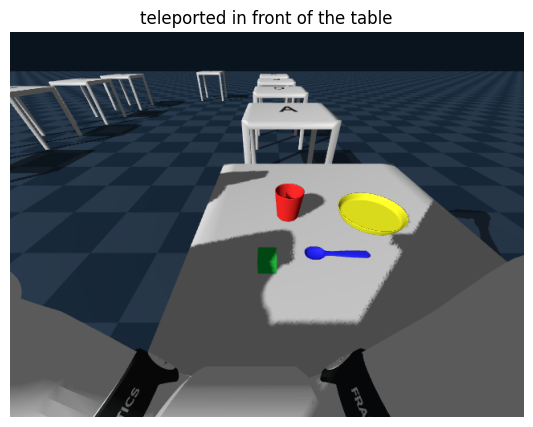

cube at: [-1.82  3.18  0.77]
right TCP start: [-2.51   3.302  1.1  ]


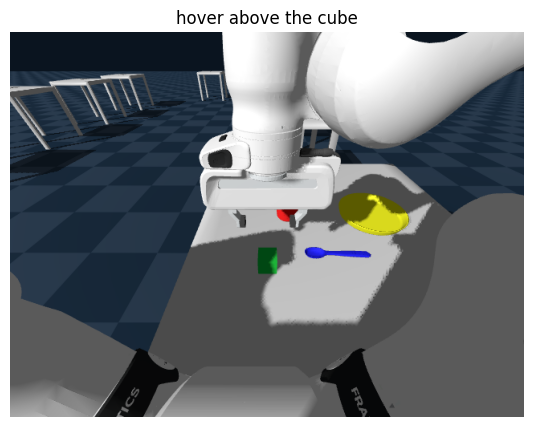

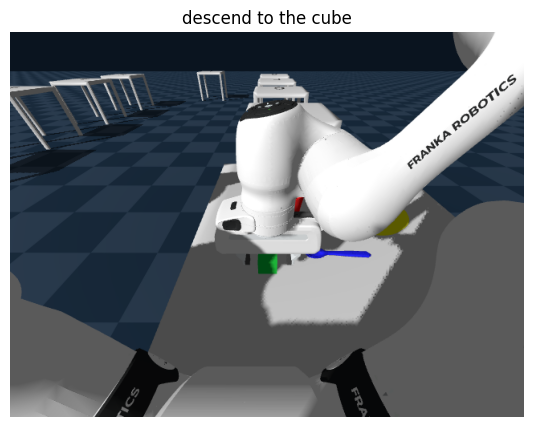

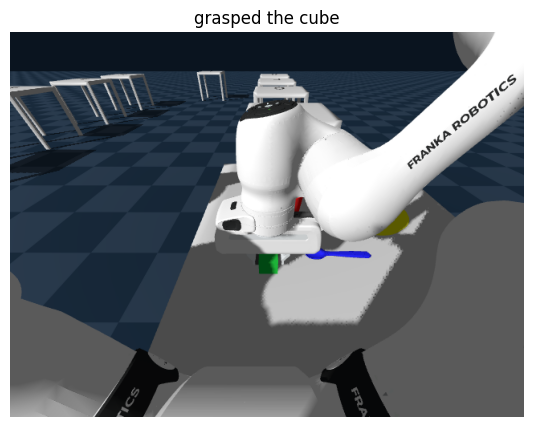

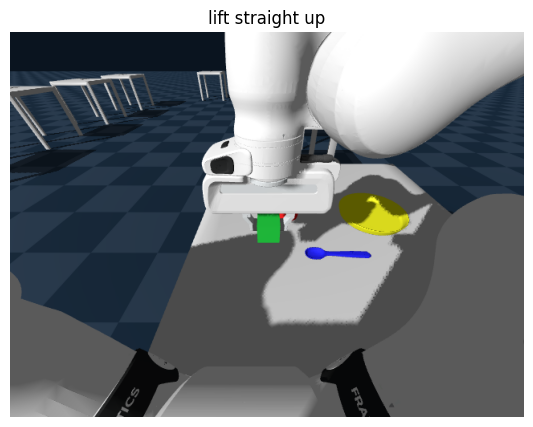

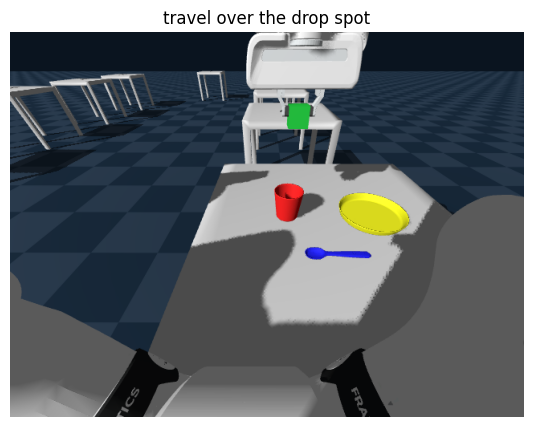

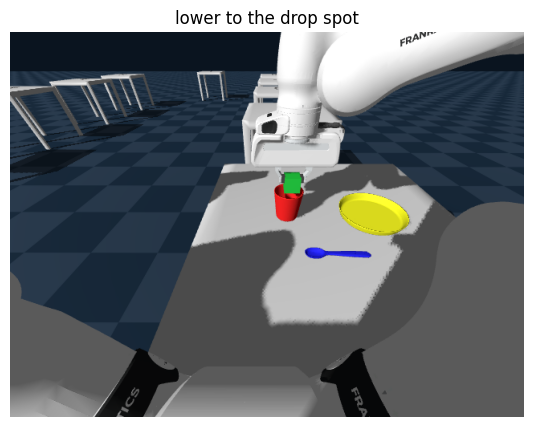

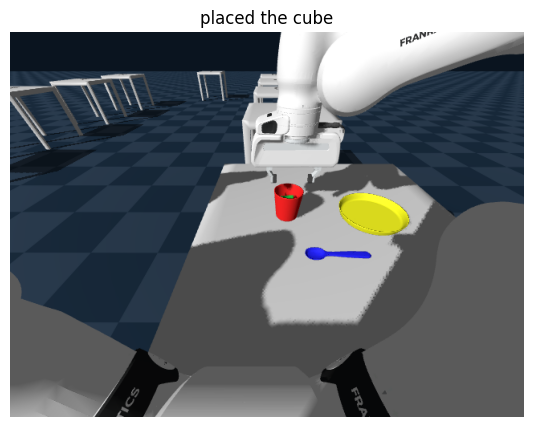

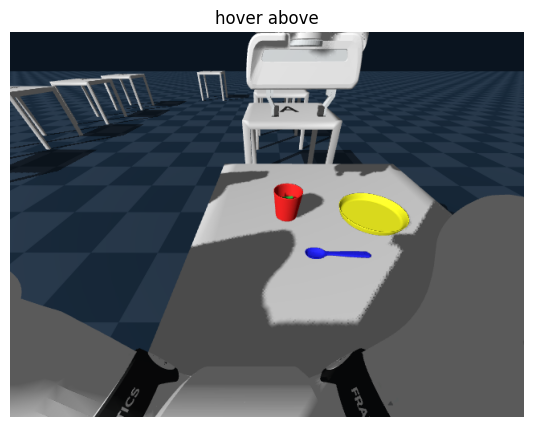

cube final pos: [-1.872  2.999  0.785]


In [ ]:
# --- 0. reset the arms to the tucked hold pose (undo the earlier joint/IK moves) ---
sim.scene.reset()
sim.reset_pose()

# --- 1. teleport to the OPEN FRONT (+y) side of the cutlery table, facing it (-y) ---
# Approaching from +x would drive the wide base into the table; the +y side is open
# (next table is 1.5 m away), so the body clears while the arm can still reach over.
# yaw=-pi/2 -> body +x points to world -y (toward the table); head cam looks at it.
sim.teleport_base(-1.8, 3.90, yaw=-np.pi / 2)
show(sim.render_head(), "teleported in front of the table")

# --- 2. read the cube's live pose (it has settled onto the table) ---
cube = sim.cube.get_pos().cpu().numpy()
print("cube at:", np.round(cube, 3))

side = "right"
APPROACH = np.array([0.0, 0.0, 0.15])   # 15 cm above a target before descending
# Don't drive the TCP all the way to the cube centre, or the fingertips reach the
# tabletop. Grip the upper part of the 4 cm cube: descend to centre + ~2 cm so the
# fingertips stay clear of the table.
GRASP = np.array([0.0, 0.0, 0.05])      # grasp-height clearance above the cube centre
# DROP_SPOT = np.array([-1.82, 3.55, 0.12])  # drop spot: open floor in front of the table
# DROP_SPOT = np.array([-2.12, 3, 0.85])  # drop spot: Plate
DROP_SPOT = np.array([-1.88, 3, 0.92])  # drop spot: Bowl



# --- 3. right-arm pick-and-place ---
sim.set_spine(0.3)
sim.set_gripper(side, 0.04)             # open
sim.step(200)
print("right TCP start:", np.round(sim.get_ee_pos(side), 3))

sim.move_ee(side, tuple(cube + APPROACH))   # hover above the cube
sim.step(200)
show(sim.render_head(), "hover above the cube")

sim.move_ee(side, tuple(cube + GRASP))      # descend to grasp height (above the tabletop)
sim.step(200)
show(sim.render_head(), "descend to the cube")

sim.set_gripper(side, 0.0)                  # close on the cube
sim.step(200)
show(sim.render_head(), "grasped the cube")

sim.move_ee(side, tuple(cube + APPROACH))   # lift straight up
sim.step(200)
show(sim.render_head(), "lift straight up")

sim.move_ee(side, tuple(DROP_SPOT + APPROACH)) # travel over the drop spot
sim.step(200)
show(sim.render_head(), "travel over the drop spot")

sim.move_ee(side, tuple(DROP_SPOT))            # lower to the floor
sim.step(200)
show(sim.render_head(), "lower to the drop spot")

sim.set_gripper(side, 0.04)                 # release
sim.step(200)
show(sim.render_head(), "placed the cube")

sim.move_ee(side, tuple(DROP_SPOT + APPROACH))   # hover above
sim.step(200)
show(sim.render_head(),"hover above")

print("cube final pos:", np.round(sim.cube.get_pos().cpu().numpy(), 3))

## 5. Save and embed the recorded video

Everything above was recorded (we called `start_recording()` in step 1). Write it to an
mp4 and embed it inline — the second way to visualize the run.

In [ ]:
from IPython.display import Video

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _HERE = os.path.abspath(".")

top_path, head_path = sim.save_video(os.path.join(_HERE, "videos", "robot_scene_demo.mp4"))
display(Video(top_path, embed=True, width=720))
display(Video(head_path, embed=True, width=720))

[video] nothing recorded (save_video=False / start_recording not called)


TypeError: cannot unpack non-iterable NoneType object